<a href="https://colab.research.google.com/github/albert-magarire/Data-Science-and-ML/blob/main/ZIMKAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏗️ ZimKAG — Legal-BERT Training Notebook

**Development of a Supervised NLP Model to Assist in Identification of Risks and Opportunities in Bespoke Construction Contracts in Zimbabwe**

Robert T. Magarire · MSc Quantity Surveying · University of Zimbabwe
Supervised by W. Gumindoga & T. Chihombori

---

This notebook trains a 5-class Legal-BERT classifier on the 10 000-clause
construction-contract dataset and saves it to Google Drive. The interactive
web interface lives in **`zimkag_webapp/`** and is run locally — see
`zimkag_webapp/README.md`.

**Run order:** execute every cell top-to-bottom. The full pipeline takes
roughly 15–25 min on a Colab T4 GPU.


## 1 · Environment setup

In [1]:
# Install dependencies (run once per Colab session)
!pip install -q transformers==4.45.2 datasets==3.0.1 accelerate==0.34.2 \
               sentence-transformers==3.2.0 scikit-learn==1.5.2 \
               matplotlib seaborn networkx==3.3 rapidfuzz==3.10.0

import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.2/255.2 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 179.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

## 2 · Upload the dataset

Upload `construction_contracts_dataset.csv` (10 000 rows, 7 columns).


In [2]:
from google.colab import files
uploaded = files.upload()  # → construction_contracts_dataset.csv


Saving construction_contracts_dataset.csv to construction_contracts_dataset (1).csv


## 3 · Load and prepare data

Schema: `text · risk_level · clause_type · one_sided · jurisdiction · contract_type · notes`

The 5-class `risk_level` is mapped to integer labels for the model:


In [3]:
import pandas as pd

df = pd.read_csv("construction_contracts_dataset.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nRisk level distribution:")
print(df['risk_level'].value_counts())
print("\nContract type distribution:")
print(df['contract_type'].value_counts())

# Drop exact duplicate clauses
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"\nAfter dedup: {len(df)} rows")

# 5-class label map
LABEL2ID = {"high": 0, "medium": 1, "low": 2, "opportunity": 3, "neutral": 4}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

df['label'] = df['risk_level'].map(LABEL2ID)
assert df['label'].isna().sum() == 0, "Some risk_level values failed to map"

print("\nFinal label counts:")
print(df['label'].value_counts().sort_index().rename(index=ID2LABEL))


Shape: (10000, 7)

Columns: ['text', 'risk_level', 'clause_type', 'one_sided', 'jurisdiction', 'contract_type', 'notes']

Risk level distribution:
risk_level
high           2435
low            2269
medium         2181
neutral        1995
opportunity    1120
Name: count, dtype: int64

Contract type distribution:
contract_type
bespoke    3659
JCT        2914
NEC4       2163
FIDIC      1264
Name: count, dtype: int64

After dedup: 3126 rows

Final label counts:
label
high           870
medium         739
low            924
opportunity    359
neutral        234
Name: count, dtype: int64


## 4 · Stratified train / validation / test split

In [4]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
print(f"Train {len(train_df)}  |  Val {len(val_df)}  |  Test {len(test_df)}")

MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

train_ds = Dataset.from_pandas(train_df[['text','label']]).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df[['text','label']]).map(tokenize,   batched=True)
test_ds  = Dataset.from_pandas(test_df[['text','label']]).map(tokenize,  batched=True)
print("✅ Tokenisation complete.")


Train 2188  |  Val 469  |  Test 469


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/2188 [00:00<?, ? examples/s]

Map:   0%|          | 0/469 [00:00<?, ? examples/s]

Map:   0%|          | 0/469 [00:00<?, ? examples/s]

✅ Tokenisation complete.


## 5 · Fine-tune Legal-BERT (5-class)

In [5]:
import numpy as np
from sklearn.metrics import f1_score
from transformers import (AutoModelForSequenceClassification, Trainer,
                          TrainingArguments, DataCollatorWithPadding)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, preds, average="weighted")}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

training_args = TrainingArguments(
    output_dir="./zimkag_legalbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)

trainer.train()
print("✅ Training complete.")


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,F1
1,1.226700,0.721159,0.776024
2,0.417200,0.239333,0.942636
3,0.141500,0.162004,0.963529
4,0.074900,0.153134,0.965727


✅ Training complete.


## 6 · Held-out test-set evaluation


Accuracy : 0.9638
Weighted F1: 0.9639  |  Precision: 0.9645  |  Recall: 0.9638

=== Classification report ===
              precision    recall  f1-score   support

        high     0.9920    0.9466    0.9688       131
      medium     0.9820    0.9820    0.9820       111
         low     0.9296    0.9565    0.9429       138
 opportunity     0.9818    1.0000    0.9908        54
     neutral     0.9167    0.9429    0.9296        35

    accuracy                         0.9638       469
   macro avg     0.9604    0.9656    0.9628       469
weighted avg     0.9645    0.9638    0.9639       469



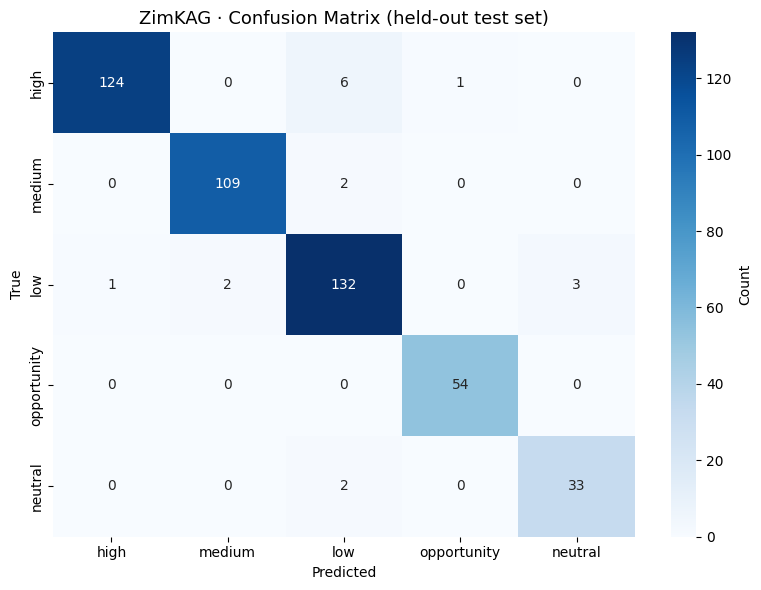

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, accuracy_score)

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=-1)
labels_in_order = [ID2LABEL[i] for i in range(NUM_LABELS)]

print(f"\nAccuracy : {accuracy_score(y_true, y_pred):.4f}")
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
print(f"Weighted F1: {f1:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, target_names=labels_in_order, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_in_order, yticklabels=labels_in_order,
            cbar_kws={'label': 'Count'})
plt.title('ZimKAG · Confusion Matrix (held-out test set)', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()


## 7 · Per-class precision / recall / F1

      class  precision   recall       f1  support
       high   0.992000 0.946565 0.968750      131
     medium   0.981982 0.981982 0.981982      111
        low   0.929577 0.956522 0.942857      138
opportunity   0.981818 1.000000 0.990826       54
    neutral   0.916667 0.942857 0.929577       35


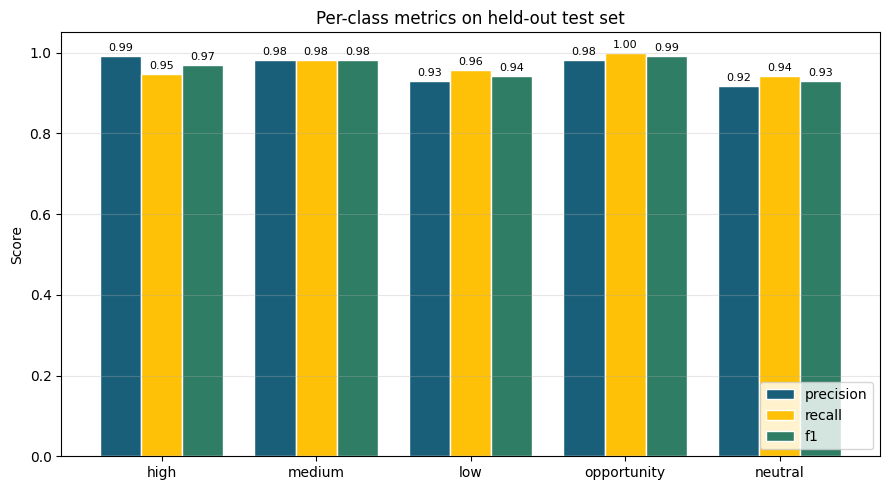

In [7]:
prec, rec, f1, supp = precision_recall_fscore_support(y_true, y_pred, average=None,
                                                       labels=list(range(NUM_LABELS)))

metrics_df = pd.DataFrame({
    'class':     labels_in_order,
    'precision': prec,
    'recall':    rec,
    'f1':        f1,
    'support':   supp,
})
print(metrics_df.to_string(index=False))

ax = metrics_df.set_index('class')[['precision','recall','f1']].plot(
    kind='bar', figsize=(9, 5),
    color=['#1a5f7a', '#ffc107', '#2e7d64'], width=0.8, edgecolor='white',
)
ax.set_title('Per-class metrics on held-out test set')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_xlabel('')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
for c in ax.containers: ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 8 · 5-fold stratified cross-validation

This block fine-tunes a fresh Legal-BERT on each fold and reports per-fold
F1, mean F1 and 95 % confidence intervals. **It takes ~1 hour on a T4** —
skip it if you only need the deployed model.



━━━━━━━━━━ Fold 1/5 ━━━━━━━━━━


Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/626 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,F1
1,1.263900,0.570043,0.823894
2,0.346900,0.225734,0.953612
3,0.180000,0.194169,0.956741


...

Map:   0%|          | 0/2501 [00:00<?, ? examples/s]

Map:   0%|          | 0/625 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,F1
1,1.350700,0.723928,0.772018
2,0.485200,0.348541,0.908802
3,0.290500,0.215734,0.958421


Fold 5: F1 = 0.9584  Acc = 0.9584

=== 5-fold CV summary ===
Weighted F1 : 0.9511 ± 0.0057  (95% CI ±0.0050)
Accuracy    : 0.9511 ± 0.0058
Per-fold F1 : ['0.9567', '0.9440', '0.9459', '0.9504', '0.9584']


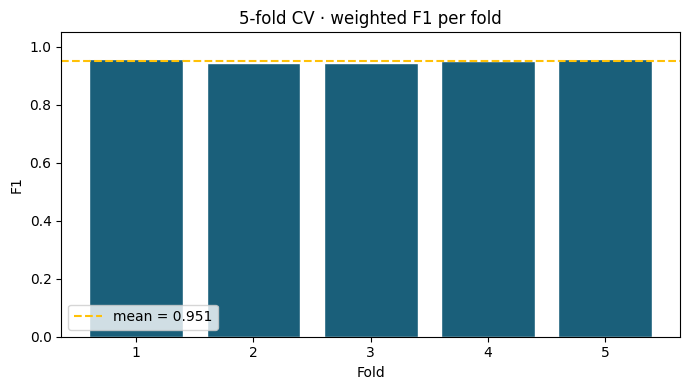

In [8]:
# OPTIONAL: 5-fold cross-validation for thesis statistics
from sklearn.model_selection import StratifiedKFold

RUN_CV = True   # ← set to False to skip
if RUN_CV:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1, fold_acc = [], []
    X = df['text'].values; y = df['label'].values

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n━━━━━━━━━━ Fold {fold}/5 ━━━━━━━━━━")
        tr_df = df.iloc[tr_idx]; va_df = df.iloc[va_idx]
        tr_ds = Dataset.from_pandas(tr_df[['text','label']]).map(tokenize, batched=True)
        va_ds = Dataset.from_pandas(va_df[['text','label']]).map(tokenize, batched=True)

        m = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID,
        )
        ta = TrainingArguments(
            output_dir=f"./cv_fold_{fold}",
            num_train_epochs=3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            learning_rate=2e-5,
            weight_decay=0.01,
            fp16=torch.cuda.is_available(),
            eval_strategy="epoch",
            save_strategy="no",
            report_to="none",
            logging_steps=100,
        )
        tr = Trainer(model=m, args=ta, train_dataset=tr_ds, eval_dataset=va_ds,
                     tokenizer=tokenizer, compute_metrics=compute_metrics,
                     data_collator=DataCollatorWithPadding(tokenizer=tokenizer))
        tr.train()
        p = tr.predict(va_ds)
        yt = p.label_ids; yp = np.argmax(p.predictions, axis=-1)
        f = f1_score(yt, yp, average='weighted'); a = accuracy_score(yt, yp)
        print(f"Fold {fold}: F1 = {f:.4f}  Acc = {a:.4f}")
        fold_f1.append(f); fold_acc.append(a)

        del m, tr; torch.cuda.empty_cache()

    fold_f1 = np.array(fold_f1); fold_acc = np.array(fold_acc)
    ci = 1.96 * fold_f1.std() / np.sqrt(len(fold_f1))
    print("\n=== 5-fold CV summary ===")
    print(f"Weighted F1 : {fold_f1.mean():.4f} ± {fold_f1.std():.4f}  (95% CI ±{ci:.4f})")
    print(f"Accuracy    : {fold_acc.mean():.4f} ± {fold_acc.std():.4f}")
    print(f"Per-fold F1 : {[f'{x:.4f}' for x in fold_f1]}")

    plt.figure(figsize=(7, 4))
    plt.bar(range(1, 6), fold_f1, color='#1a5f7a', edgecolor='white')
    plt.axhline(fold_f1.mean(), color='#ffc107', ls='--', label=f'mean = {fold_f1.mean():.3f}')
    plt.title('5-fold CV · weighted F1 per fold'); plt.xlabel('Fold'); plt.ylabel('F1')
    plt.ylim(0, 1.05); plt.legend(); plt.tight_layout(); plt.show()
else:
    print("Skipping 5-fold CV (RUN_CV=False).")


## 9 · Save the trained model to Google Drive

After this cell completes, **download the entire `zimkag_legalbert_5class/`
folder** from your Drive and drop it into:

```
zimkag_webapp/models/zimkag_legalbert_5class/
```


In [9]:
import os, json
from google.colab import drive

drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/ZimKAG_Model/zimkag_legalbert_5class"
os.makedirs(SAVE_PATH, exist_ok=True)

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

with open(os.path.join(SAVE_PATH, "label_map.json"), "w") as f:
    json.dump({"label2id": LABEL2ID, "id2label": ID2LABEL}, f, indent=2)

print(f"✅ Saved model + label_map.json → {SAVE_PATH}")
print("Files:")
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(os.path.join(SAVE_PATH, f)) / (1024*1024)
    print(f"  {f}  ({size:.1f} MB)")


Mounted at /content/drive
✅ Saved model + label_map.json → /content/drive/MyDrive/ZimKAG_Model/zimkag_legalbert_5class
Files:
  config.json  (0.0 MB)
  label_map.json  (0.0 MB)
  model.safetensors  (417.7 MB)
  special_tokens_map.json  (0.0 MB)
  tokenizer.json  (0.7 MB)
  tokenizer_config.json  (0.0 MB)
  training_args.bin  (0.0 MB)
  vocab.txt  (0.2 MB)


## 10 · Verify the saved model with sample clauses

In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, json, os

SAVE_PATH = "/content/drive/MyDrive/ZimKAG_Model/zimkag_legalbert_5class"

tk = AutoTokenizer.from_pretrained(SAVE_PATH, local_files_only=True)
mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH, local_files_only=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mdl.to(device).eval()

with open(os.path.join(SAVE_PATH, "label_map.json")) as f:
    lmap = json.load(f)
ID2LABEL_LOADED = {int(k): v for k, v in lmap["id2label"].items()}

samples = [
    "The Contractor shall pay liquidated damages of 5% of the Contract Sum per day of delay, uncapped.",
    "The Employer shall release retention upon Practical Completion.",
    "SECTION 4 – PAYMENT",
    "Payment applications shall be submitted by the 25th of each month.",
    "Where the Engineer fails to certify on time, the Contractor's quotation is treated as accepted.",
    "All payments shall be made in United States Dollars; payment in RTGS shall not discharge the obligation.",
    "The Contractor shall indemnify the Employer against all third-party claims, whether or not caused by the Contractor's negligence.",
]
print(f"{'PREDICTION':>12s} | {'CONF':>5s} | CLAUSE")
print("─" * 110)
for t in samples:
    enc = tk(t, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        probs = torch.softmax(mdl(**enc).logits, dim=-1)[0]
    p = int(probs.argmax().item())
    print(f"{ID2LABEL_LOADED[p]:>12s} | {probs[p]*100:>4.1f}% | {t[:90]}")


  PREDICTION |  CONF | CLAUSE
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
        high | 97.4% | The Contractor shall pay liquidated damages of 5% of the Contract Sum per day of delay, un
         low | 99.0% | The Employer shall release retention upon Practical Completion.
     neutral | 98.2% | SECTION 4 – PAYMENT
         low | 80.8% | Payment applications shall be submitted by the 25th of each month.
 opportunity | 97.7% | Where the Engineer fails to certify on time, the Contractor's quotation is treated as acce
        high | 99.1% | All payments shall be made in United States Dollars; payment in RTGS shall not discharge t
        high | 99.2% | The Contractor shall indemnify the Employer against all third-party claims, whether or not


## 11 · Next: launch the web interface

The web app is a **standalone application** — no Colab required. From your
local machine:

1. Download the entire `zimkag_legalbert_5class/` folder from Google Drive.
2. Place it inside the project at: `zimkag_webapp/models/zimkag_legalbert_5class/`
3. Copy `zimkag_webapp/.env.example` → `zimkag_webapp/.env` and add your
   `GROQ_API_KEY` (free key from <https://console.groq.com/keys>).
4. Double-click `zimkag_webapp/run.bat` (Windows) or `./run.sh` (macOS / Linux).
5. Open <http://127.0.0.1:8000> in your browser.

See `zimkag_webapp/README.md` for full documentation, API reference and
production-deployment notes.
